In [2]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [20]:
# Get best parameters for train data

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

result_list = []

alpha_list = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e+1, 1e+2, 1e+3]

for alpha in alpha_list:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'alpha': alpha} 
    result = {'score': score, 'params': params}
    result_list.append(result)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

result_list.sort(key=lambda x: x['score'], reverse=True)
result_list

Max Score: 0.7527461826467725
Best Params: {'alpha': 0.0001}


[{'score': 0.7527461826467725, 'params': {'alpha': 0.0001}},
 {'score': 0.7527461826467724, 'params': {'alpha': 0.001}},
 {'score': 0.7527461826467724, 'params': {'alpha': 0.01}},
 {'score': 0.7527461826467723, 'params': {'alpha': 1e-05}},
 {'score': 0.7527461826467661, 'params': {'alpha': 0.1}},
 {'score': 0.7527461826461225, 'params': {'alpha': 1}},
 {'score': 0.7527461825817795, 'params': {'alpha': 10.0}},
 {'score': 0.7527461761485638, 'params': {'alpha': 100.0}},
 {'score': 0.7527455339113146, 'params': {'alpha': 1000.0}}]

Here we noticed that alpha is not affecting the score, so we keep alpha as 1 

In [23]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.7651981318966635


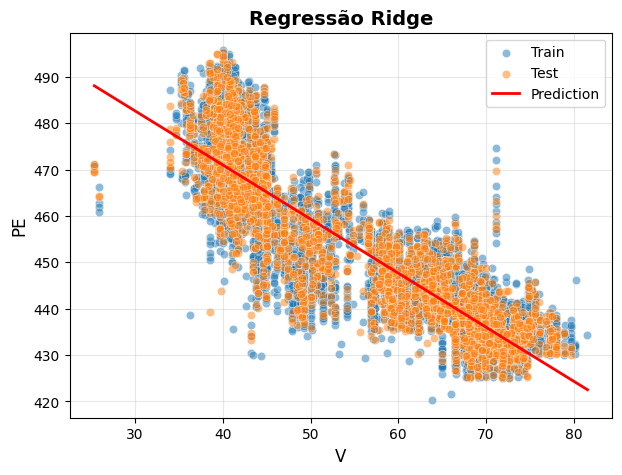

In [24]:
from utils import plot_predictions

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Regressão Ridge', name='Images/ridge_regression.png')